# Homework #4

## Regularization in Machine Learning

This colaboratory contains Homework #4 of the Machine Learning course. To complete the homework, extract **(File -> Download .ipynb)** and submit to the course webpage.


## Submission's rules:

1.   Please, submit only .ipynb that you extract from the Colaboratory.
2. Run your homework exercises before submitting (output should be present, preferably restart the kernel and press run all the cells).
3. Do not change the description of tasks in red (even if there is a typo|mistake|etc).
4. Please, make sure to avoid unnecessary long printouts.
5. Each task should be solved right under the question of the task and not elsewhere.
6. Solutions to both regular and bonus exercises should be submitted in one IPYNB file.

##List of Homework's exercises:

1.   [Ex1](#scrollTo=gCUvnKxZXTul) - 3 points
2.   [Ex2](#scrollTo=yLmunCZ9k-G6) - 4 points
3.   [Ex3](#scrollTo=lPdnuVSqeIN2) - 3 points
4.   [Bonus 1](#scrollTo=piaKpOh8If7h) - 2 points
5.   [Bonus 2](#scrollTo=jdZkblZW7bEp) - up to 4 points (based on quality of presentation)


In [2]:
!pip install -q plotnine
from plotnine import *

import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf

import matplotlib.pyplot as plt

# loading in the cifar10 dataset
from keras.datasets import cifar10
from keras.layers import Input, Conv2D, Activation, Flatten, Dense, MaxPooling2D, BatchNormalization, Dropout
from keras import regularizers, optimizers, Sequential

In [5]:
# Auxiliary functions
def plot_curves(history):
  plt.figure(figsize=(16, 6))

  plt.subplot(1, 2, 1)
  plt.plot(history.history['loss'])
  plt.plot(history.history['val_loss'])
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend(['Training', 'Validation'])
  plt.title('Loss')

  plt.subplot(1, 2, 2)
  plt.plot(history.history['accuracy'])
  plt.plot(history.history['val_accuracy'])
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.legend(['Training', 'Validation'])
  plt.title('Accuracy')

def define_model(lambda_):
  model = Sequential()
  model.add(Conv2D(32, (3,3), padding='same', kernel_regularizer=regularizers.l2(lambda_), input_shape=(32, 32, 3)))
  model.add(Activation('relu'))
  model.add(Conv2D(32, (3,3), padding='same', kernel_regularizer=regularizers.l2(lambda_)))
  model.add(Activation('relu'))
  model.add(MaxPooling2D(pool_size=(2,2)))

  model.add(Conv2D(64, (3,3), padding='same', kernel_regularizer=regularizers.l2(lambda_)))
  model.add(Activation('relu'))
  model.add(Conv2D(64, (3,3), padding='same', kernel_regularizer=regularizers.l2(lambda_)))
  model.add(Activation('relu'))
  model.add(MaxPooling2D(pool_size=(2,2)))

  model.add(Conv2D(128, (3,3), padding='same', kernel_regularizer=regularizers.l2(lambda_)))
  model.add(Activation('relu'))
  model.add(Conv2D(128, (3,3), padding='same', kernel_regularizer=regularizers.l2(lambda_)))
  model.add(Activation('relu'))
  model.add(MaxPooling2D(pool_size=(2,2)))

  model.add(Flatten())

  model.add(Dense(100, activation='relu', kernel_regularizer=regularizers.l2(lambda_)))

  model.add(Dense(10, activation='softmax'))
  return(model)

def define_model_dropout(dropout_rate = 0):
  model = Sequential()
  model.add(Conv2D(32, (3,3), padding='same', input_shape=(32, 32, 3)))
  model.add(Activation('relu'))
  model.add(Conv2D(32, (3,3), padding='same'))
  model.add(Activation('relu'))
  model.add(MaxPooling2D(pool_size=(2,2)))
  model.add(Dropout(dropout_rate))

  model.add(Conv2D(64, (3,3), padding='same'))
  model.add(Activation('relu'))
  model.add(Conv2D(64, (3,3), padding='same'))
  model.add(Activation('relu'))
  model.add(MaxPooling2D(pool_size=(2,2)))
  model.add(Dropout(dropout_rate))

  model.add(Conv2D(128, (3,3), padding='same'))
  model.add(Activation('relu'))
  model.add(Conv2D(128, (3,3), padding='same'))
  model.add(Activation('relu'))
  model.add(MaxPooling2D(pool_size=(2,2)))
  model.add(Dropout(dropout_rate))

  model.add(Flatten())

  model.add(Dense(100, activation='relu'))
  model.add(Dropout(dropout_rate))

  model.add(Dense(10, activation='softmax'))
  return(model)

## Homework exercise 1 (3 points): ElasticNet algorithm combines both Ridge and LASSO regression.
<font color='red'> In the class we discussed Ridge and Lasso regression algorithms, which are basically, L2 and L1 regularisations applied to Linear Regression model. ElasticNet is a method that combines both L2 and L1 regularisations under one model. ElasticNet adds both L2 and L1 norms to the error function. Here you should train and visualise ElasticNet model on the toy dataset. </font>


In [3]:
# Let's regenerate training data one more time
example_data = pd.DataFrame({'x':[1,2,3,4,5], 'y':[2,4,5,4,5]})
example_data['x^2'] = example_data.x**2
example_data['x^3'] = example_data.x**3
example_data['x^4'] = example_data.x**4

visualisation_data = pd.DataFrame({'x': np.linspace(start=0, stop=6, num=61),
                          'x^2': np.linspace(start=0, stop=6, num=61)**2,
                          'x^3': np.linspace(start=0, stop=6, num=61)**3,
                          'x^4': np.linspace(start=0, stop=6, num=61)**4})

<font color='red'> **(Homework exercise 1- a)** Train ElasticNet as well as three other regression models (linear, ridge and lasso) using `sklearn` on example data. **(1 point)**. </font>

In [4]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet

# Regularization strength
lambda_ = 1

##### YOUR CODE STARTS #####
# first initialise different regressions
# then fit them to our example_data
# finally predict the visualisation data
lr = LinearRegression()
ridge = Ridge(alpha=lambda_)
lasso = Lasso(alpha=lambda_)
elastic_net = ElasticNet(alpha=lambda_, l1_ratio=0.5)

X_train = example_data[['x', 'x^2', 'x^3', 'x^4']]
y_train = example_data['y']

lr.fit(X_train, y_train)
ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)
elastic_net.fit(X_train, y_train)

X_vis = visualisation_data[['x', 'x^2', 'x^3', 'x^4']]
visualisation_data['lr_y'] = lr.predict(X_vis)
visualisation_data['ridge_y'] = ridge.predict(X_vis)
visualisation_data['lasso_y'] = lasso.predict(X_vis)
visualisation_data['elasticnet_y'] = elastic_net.predict(X_vis)
##### YOUR CODE ENDS #####

<font color='red'> **(Homework exercise 1- b)** Visualise all four regression trends (baseline, LASSO, Ridge and ElasticNet) on the same figure. Highlight ElasticNet in <font color='#F1C40F'>yellow</font>, while others in black (linear), red (ridge) and blue (lasso). **(1 point)**. </font>


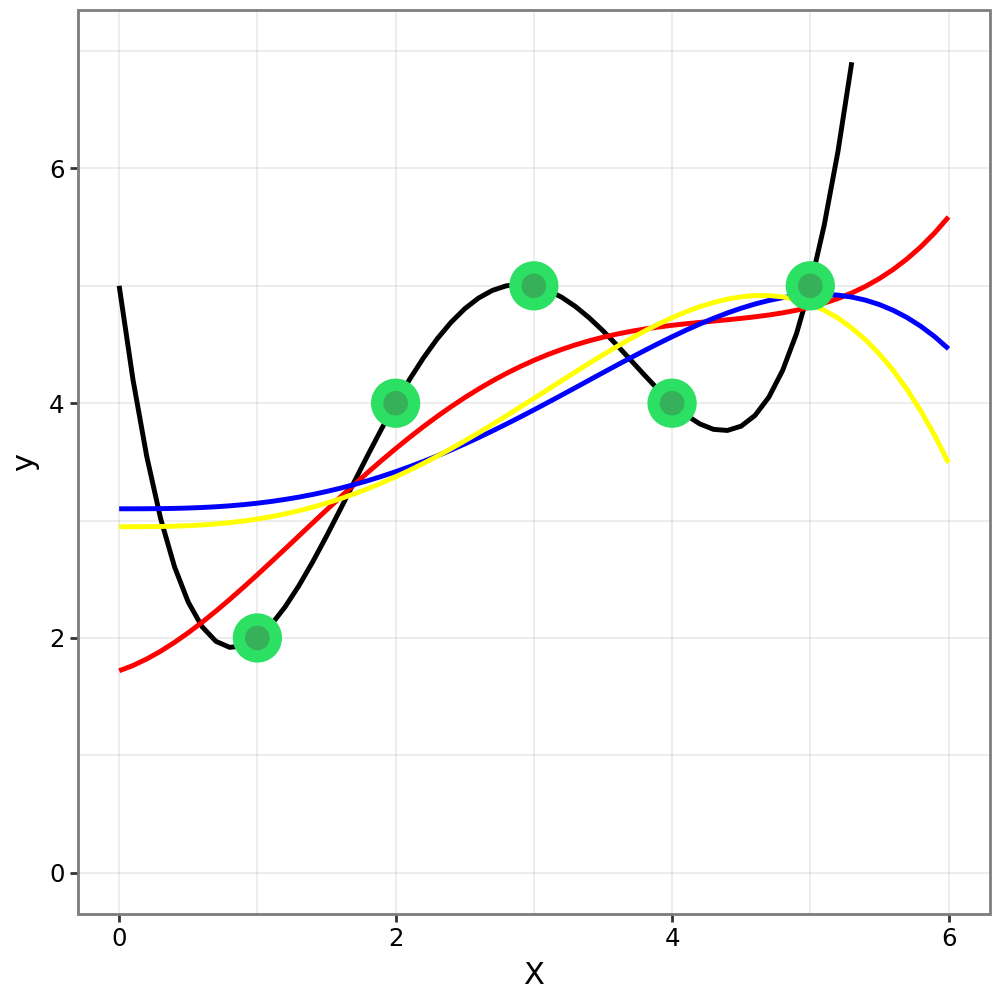

In [5]:
fig = (
    ggplot(data = example_data,
          mapping = aes(x = 'x', y = 'y')) +
       ##### YOUR CODE STARTS #####
       geom_path(data = visualisation_data, mapping = aes(x = 'x', y = 'lr_y'), color = 'black', size = 1.0) +
       geom_path(data = visualisation_data, mapping = aes(x = 'x', y = 'ridge_y'), color = 'red', size = 1.0) +
       geom_path(data = visualisation_data, mapping = aes(x = 'x', y = 'lasso_y'), color = 'blue', size = 1.0) +
       geom_path(data = visualisation_data, mapping = aes(x = 'x', y = 'elasticnet_y'), color = 'yellow', size = 1.0) +
       ##### YOUR CODE ENDS #####
    geom_point(fill = '#36B059',
               size = 5.0,
               stroke = 2.5,
               colour = '#2BE062',
               shape = 'o') +
    labs(
        title ='',
        x = 'X',
        y = 'y',
    ) +
    xlim(0, 6) +
    ylim(0, 7) +
    theme_bw() +
    theme(figure_size = (5, 5),
          axis_line = element_line(size = 0.5, colour = "black"),
          panel_grid_major = element_line(size = 0.05, colour = "black"),
          panel_grid_minor = element_line(size = 0.05, colour = "black"),
          axis_text = element_text(colour ='black')) +
    guides(size = False)
)
fig

<font color='red'> **(Homework exercise 1- c)** Print out ElasticNet coefficients and intercept, compare it to coefficients and intercept of other regressions. Which one ElasticNet seems to be more similar to? Which parameter in `sklearn.ElasticNet` function is responsible for mixing of L1 and L2 regularisation? **(1 point)**. </font>

In [6]:
##### YOUR CODE STARTS #####
print(f'ElasticNet regression coefficients are: {elastic_net.coef_}')
print(f'ElasticNet regression intercept is: {elastic_net.intercept_}')
print("\n")

print(f'Linear regression coefficients are: {lr.coef_}')
print(f'Linear regression intercept is: {lr.intercept_}')
print("\n")

print(f'Ridge regression coefficients are: {ridge.coef_}')
print(f'Ridge regression intercept is: {ridge.intercept_}')
print("\n")

print(f'Lasso regression coefficients are: {lasso.coef_}')
print(f'Lasso regression intercept is: {lasso.intercept_}')
print("\n")
##### YOUR CODE ENDS #####

ElasticNet regression coefficients are: [ 0.          0.          0.07844547 -0.01265445]
ElasticNet regression intercept is: 2.94769509875881


Linear regression coefficients are: [-8.75        7.79166667 -2.25        0.20833333]
Linear regression intercept is: 5.0000000000009095


Ridge regression coefficients are: [ 0.3882215   0.61877466 -0.20687874  0.0184773 ]
Ridge regression intercept is: 1.7205023752825568


Lasso regression coefficients are: [ 0.          0.          0.05608653 -0.00829621]
Lasso regression intercept is: 3.1005045969630998




<font color='red'> Your textual answer goes here: </font>

**Which one ElasticNet seems to be more similar to ?**

The ElasticNet coefficients are much more similar to the Lasso coefficients. Both have first two coefficients exactly zero, small positive third coefficient and small negative fourth coefficient. Also similar are their intercepts.

**Comparison of the methods:**

The Linear regression model has large coefficient values and shows signs of overfitting, as evident in the graph where it oscillates to fit all points exactly. The Ridge regression has non-zero values for all coefficients but they're smaller compared to Linear regression.

The visualization confirms this analysis:

* ElasticNet (<font color='yellow'> yellow </font>) follows a similar path to the Lasso (<font color='blue'> blue </font>)
* Ridge (<font color='red'> red </font>) is smoother than Linear but still more flexible than Lasso/ElasticNet
* Linear (black) overfits the data points

**Which parameter in sklearn.ElasticNet function is responsible for mixing of L1 and L2 regularisation?**

The parameter is l1_ratio. Since I used l1_ratio=0.5, I gave equal weight to both regularization types, but the resulting model still behaves more like Lasso because L1 regularization's feature selection property is zeroing out coefficients, and it tends to be dominant even with equal weighting.

l1_ratio=0 corresponds to pure L1 Ridge, l1_ratio=1 corresponds to pure L1 Lasso.

## Homework exercise 2 (4 points): searching for good dropout rate
<font color='red'> Use `sklearn` function (`KFold`) for cross-validation to find the best possible dropout rate for the neural network we used in the class (that you call via `define_model_dropout`). </font>

In [3]:
# Keras comes with built-in loaders for common datasets
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# shorten dataset for quicker training
X_train = X_train[:25000]
y_train = y_train[:25000]

# Normalising values
mu = X_train.mean(axis=(0,1,2)) # finds mean of R, G and B separately
std = X_train.std(axis=(0,1,2)) # same for std
X_train_norm = (X_train - mu)/std
X_test_norm = (X_test - mu)/std

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


<font color='red'> **(Homework exercise 2- a)** Run cross-validation by filling in the gaps and collect validation accuracy scores for each dropout rate. **(2 points)**. </font>


In [8]:
from sklearn.model_selection import KFold
dropout_rates = [0.0, 0.1, 0.25, 0.5, 0.99] # feel free to choose other values to loop over

# you can collect both accuracy and loss if you like,
# but loss is influenced by the regularisation itself, so maybe less informative
val_fold_acc = np.zeros(len(dropout_rates))
val_fold_loss = np.zeros(len(dropout_rates))

for i, dropout_rate in enumerate(dropout_rates):
  print(f'Validation loss for dropout rate = {dropout_rate}...')
  ##### YOUR CODE STARTS #####
  # 4-fold cross validation
  # Here we are using sklearn Cross Validation Function called KFold
  kf = KFold(n_splits=4, shuffle=True, random_state=111)

  # Do not change these lines, we initialize empty lists
  fold_acc = []
  fold_loss = []
  for train_index, val_index in kf.split(X_train_norm):

    # split data into train_X, train_y and val_X, val_y depending on the fold:
    train_X = X_train_norm[train_index]
    train_y = y_train[train_index]
    val_X = X_train_norm[val_index]
    val_y = y_train[val_index]

    # train the neural network with dropout_rate
    model = define_model_dropout(dropout_rate)

    # compile the model
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # fit the neural network on training data
    # number of epochs is tricky, if you choose too little the performance will be unstable
    # if you choose too large, it will take ages to complete...
    model.fit(train_X, train_y, epochs=10, batch_size=64, validation_data=(val_X, val_y), verbose=0)

    # calculate accuracy for this fold and store it in fold_acc
    scores = model.evaluate(val_X, val_y, verbose=0)

    # and loss in fold_loss
    fold_loss.append(scores[0])
    fold_acc.append(scores[1])
    ##### YOUR CODE ENDS #####

  print(f'Average validation accuracy for {dropout_rate} is {np.mean(fold_acc)}')
  val_fold_acc[i] = np.mean(fold_acc)
  val_fold_loss[i] = np.mean(fold_loss)

Validation loss for dropout rate = 0.0...
Average validation accuracy for 0.0 is 0.7006799876689911
Validation loss for dropout rate = 0.1...
Average validation accuracy for 0.1 is 0.7264399975538254
Validation loss for dropout rate = 0.25...
Average validation accuracy for 0.25 is 0.7281999886035919
Validation loss for dropout rate = 0.5...
Average validation accuracy for 0.5 is 0.6362400054931641
Validation loss for dropout rate = 0.99...
Average validation accuracy for 0.99 is 0.09716000221669674


<font color='red'> **(Homework exercise 2- b)** Create a plot (using standard matplotlib) that shows validation accuracy and loss for different dropout rates that you have tried, report the best one. **(1 point)**. </font>


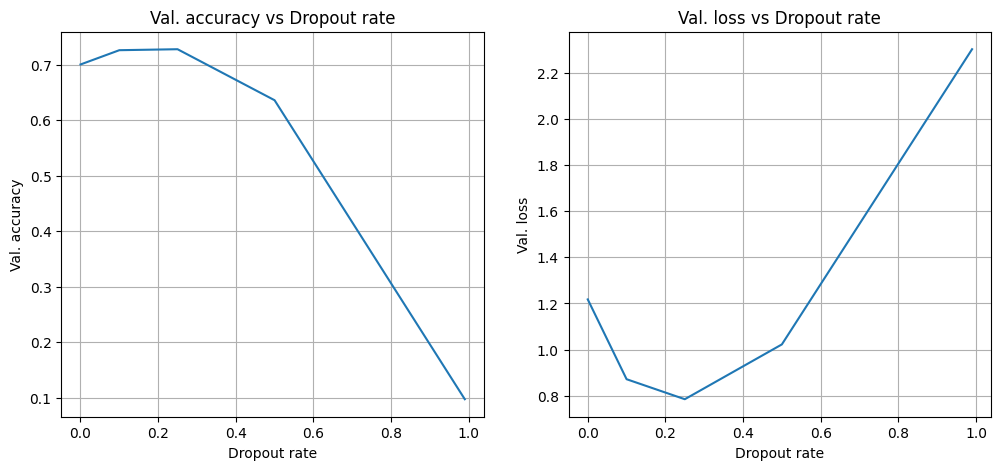

In [9]:
##### YOUR CODE STARTS #####
# Plot for accuracies
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(dropout_rates, val_fold_acc)
plt.title('Val. accuracy vs Dropout rate')
plt.xlabel('Dropout rate')
plt.ylabel('Val. accuracy')
plt.grid(True)

# Plot for losses
plt.subplot(1, 2, 2)
plt.plot(dropout_rates, val_fold_loss)
plt.title('Val. loss vs Dropout rate')
plt.xlabel('Dropout rate')
plt.ylabel('Val. loss')
plt.grid(True)
##### YOUR CODE ENDS #####

According to the above graphs, the best dropout rate seems to be 0.25

<font color='red'> **(Homework exercise 2- c)** Re-train the network using the dropout rate reported in **(b)**. Visualise performance curves and interpret the results. (if results did not improve, no need to re-run the process again, just comment on the results). **(1 point)**. </font>

In [8]:
##### YOUR CODE STARTS #####
# Define the model with identified dropout rate and compile it
best_dropout = 0.25
model = define_model_dropout(dropout_rate=best_dropout)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Fit the model; return history object
history = model.fit(X_train_norm, y_train,
                    epochs=20,
                    batch_size=64,
                    validation_split=0.2,
                    verbose=1)
##### YOUR CODE ENDS #####

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.2289 - loss: 2.0514 - val_accuracy: 0.4662 - val_loss: 1.4320
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4716 - loss: 1.4450 - val_accuracy: 0.5584 - val_loss: 1.2261
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5596 - loss: 1.2241 - val_accuracy: 0.5952 - val_loss: 1.1121
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6209 - loss: 1.0530 - val_accuracy: 0.6536 - val_loss: 0.9624
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6620 - loss: 0.9667 - val_accuracy: 0.6812 - val_loss: 0.8944
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6871 - loss: 0.8814 - val_accuracy: 0.7092 - val_loss: 0.8263
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7114 - loss: 0.8129 - val_accuracy: 0.7034 - val_loss: 0.8319
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7331 - loss: 0.7528 - val_accuracy: 

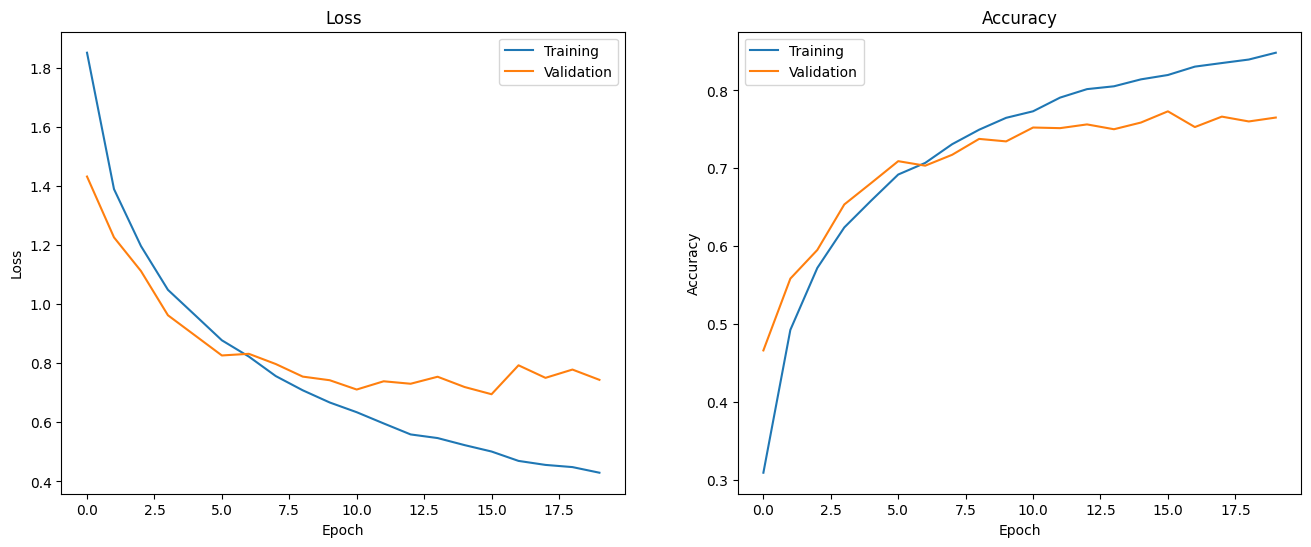

In [9]:
##### YOUR CODE STARTS #####
# plot the progress curves here
plot_curves(history)
##### YOUR CODE ENDS #####

In [10]:
##### YOUR CODE STARTS #####
# evaluate the model here
test_loss, test_acc = model.evaluate(X_test_norm, y_test, verbose=0)
print(f'Test accuracy: {test_acc:.4f}')
print(f'Test loss: {test_loss:.4f}')
##### YOUR CODE ENDS #####

Test accuracy: 0.7573
Test loss: 0.7661


<font color='red'> Your insightful interpretation of the results goes here: </font>

The model with a dropout rate of 0.25 starts off well, but we can see signs of overfitting around epoch 9–10. After that point, the validation loss stops improving and even gets a bit worse, while the training loss keeps going down. The same goes for accuracy — training keeps improving, but validation accuracy flattens out.

This shows the model is starting to memorize the training data rather than learning patterns that generalize well to new data.

Also, while dropout helped a bit, the overall performance isn’t that great — validation accuracy stays around 75–76%, which is pretty far from state-of-the-art results on CIFAR-10. This is likely because the model architecture is quite simple and data amount is not sufficient, do that model doesn’t capture the complexity of the data well.

## Homework exercise 3 (3 points): applying more sophisticated augmentation pipelines
<font color='red'> Check https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/ImageDataGenerator and add more interesting transformation into the pipeline we have developed in the class. Train your network again, and interpret the results. First of all some setup. </font>

In [11]:
# Keras comes with built-in loaders for common datasets
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# shorten dataset for quicker training
X_train = X_train[:25000]
y_train = y_train[:25000]


<font color='red'> **(Homework exercise 3- a)** Add at least 2-3 more different transformations described at https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/ImageDataGenerator. Augment CIFAR10 training images. Visualise a few random augmentated images (as we have done for the simple augmentation pipeline in the class). This time, make 5 by 5 grid instead of 3 by 3. Briefly explain your choice of augmentation pipeline (i.e. why these augmentation you added will help?). **(1 point)**. </font>


In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator # changed to up to date import version

##### YOUR CODE STARTS #####
# Create your own data augmentation pipeline:
datagen = ImageDataGenerator(
    rotation_range=90, # from class
    width_shift_range=0.1, # from class
    height_shift_range=0.1, # from class
    horizontal_flip=True, # from class
    zoom_range=0.2, # randomly zoom in/out on images
    brightness_range=[0.7, 1.3], # adjust brightness randomly
    shear_range=15 # shear angle in counter-clockwise direction in degrees
)
##### YOUR CODE ENDS #####

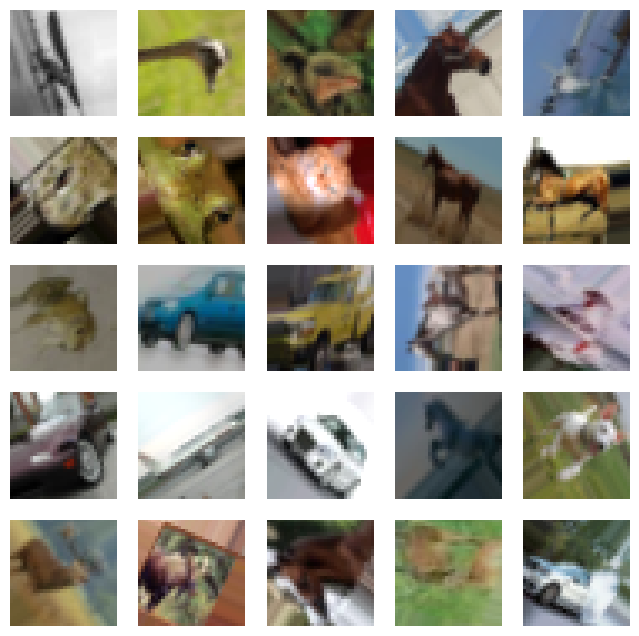

In [14]:
##### YOUR CODE STARTS #####
plt.rcParams['figure.figsize'] = (8.0, 8.0) # set default size of plots

# Configure batch size and retrieve one batch of images
for X_batch, y_batch in datagen.flow(X_train, y_train, batch_size=25):
    # Show 25 images
    for i in range(25):
        plt.subplot(5, 5, i + 1)
        plt.imshow(X_batch[i].astype('uint8'))
        plt.axis('off')
    # show the plot
    plt.show()
    break
##### YOUR CODE ENDS #####

**Explanation of new augumentation transformations:**

These transformations help simulate different real-world conditions: zoom mimics a camera moving closer or further from the object, brightness helps the model become more robust to lighting changes, shear distorts the object shape slightly, improving (I hope) generalization to new viewpoints.

<font color='red'> **(Homework exercise 3- b)** First, split the training data into train and validation sets using `train_test_split` function from `sklearn` (use 10% for validation). Then normalise each of the three sets (train, val and test) using mean and standard deviations computed on train images (for R, G and B separately). Finally, retrain the model using this new augmented training set. Use non-augmented normalised validation set for validation of the model while training. **(1.5 points)**. </font>

In [15]:
from sklearn.model_selection import train_test_split

##### YOUR CODE STARTS #####
# Split the training data further into train and val
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

mu = X_train_split.mean(axis=(0, 1, 2)) # finds mean of R, G and B separately
std = X_train_split.std(axis=(0, 1, 2)) # same for std
X_train_norm = (X_train_split - mu) / std
X_val_norm = (X_val_split - mu) / std
X_test_norm = (X_test - mu) / std
##### YOUR CODE ENDS #####

# Assign augmentation schema to X_train_norm
datagen.fit(X_train_norm)

In [22]:
##### YOUR CODE STARTS #####
# Create a model
# here you can use either model with dropout or L2 regularisation defined above
model = define_model_dropout(dropout_rate=0.25)

# Compile the model as before (code is identical)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# remember to use .fit() to train the model
# use batch_size 64 as in the class
history = model.fit(
    datagen.flow(X_train_norm, y_train_split, batch_size=64),
    epochs=100,
    validation_data=(X_val_norm, y_val_split),
    steps_per_epoch=len(X_train_norm) // 64,
    verbose=1
)
##### YOUR CODE ENDS #####

Epoch 1/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 30s 67ms/step - accuracy: 0.1767 - loss: 2.1641 - val_accuracy: 0.3580 - val_loss: 1.7474
Epoch 2/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 630us/step - accuracy: 0.2500 - loss: 1.9609 - val_accuracy: 0.3436 - val_loss: 1.7597
Epoch 3/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step - accuracy: 0.3149 - loss: 1.8324 - val_accuracy: 0.3860 - val_loss: 1.7013
Epoch 4/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 655us/step - accuracy: 0.3594 - loss: 1.7486 - val_accuracy: 0.3872 - val_loss: 1.6669
Epoch 5/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step - accuracy: 0.3669 - loss: 1.7220 - val_accuracy: 0.4072 - val_loss: 1.6215
Epoch 6/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 621us/step - accuracy: 0.4844 - loss: 1.5773 - val_accuracy: 0.4108 - val_loss: 1.6054
Epoch 7/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step - accuracy: 0.3984 - loss: 1.6398 - val_accuracy: 0.3832 - val_loss: 1.6866
Epoch 8/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 639us/step - accuracy: 0.5156 - loss: 1


<font color='red'> **(Homework exercise 3- c)** Plot the performance curves (loss and accuracy), evaluate your model on the non-augmented normalised test set and interpret the results. Did the performance improve? Why? Why not? **(0.5 points)**. </font>

### 20 epochs

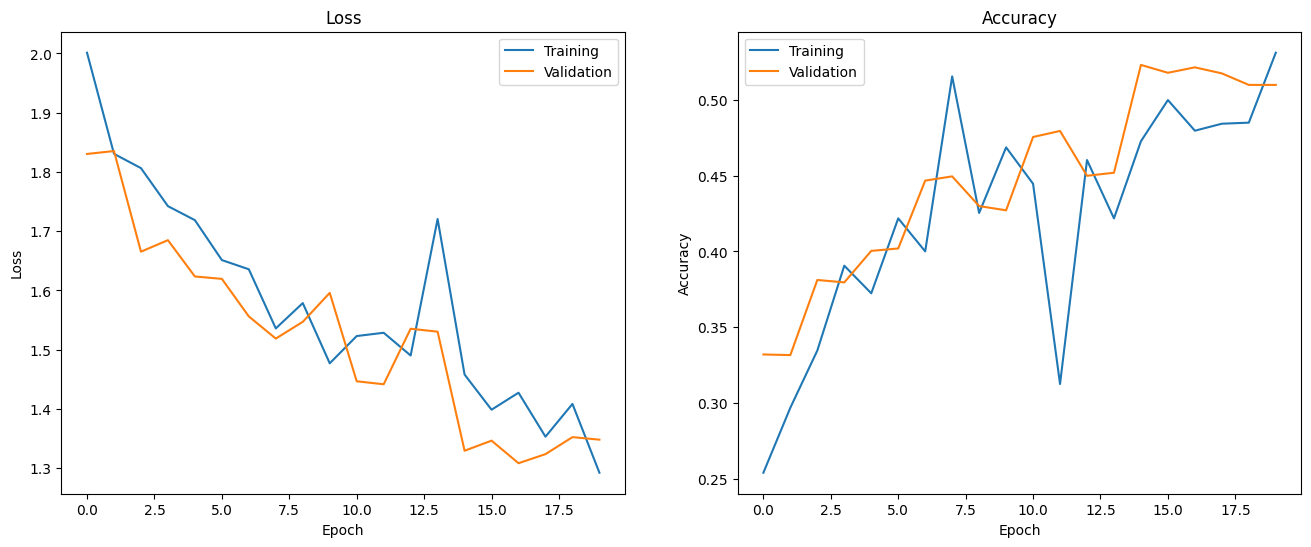

In [17]:
##### YOUR CODE STARTS #####
plot_curves(history)
##### YOUR CODE ENDS #####

In [18]:
##### YOUR CODE STARTS #####
test_loss, test_acc = model.evaluate(X_test_norm, y_test, verbose=0)
print(f'Test accuracy: {test_acc:.4f}')
print(f'Test loss: {test_loss:.4f}')
##### YOUR CODE ENDS #####

Test accuracy: 0.5194
Test loss: 1.3136


### 50 epochs

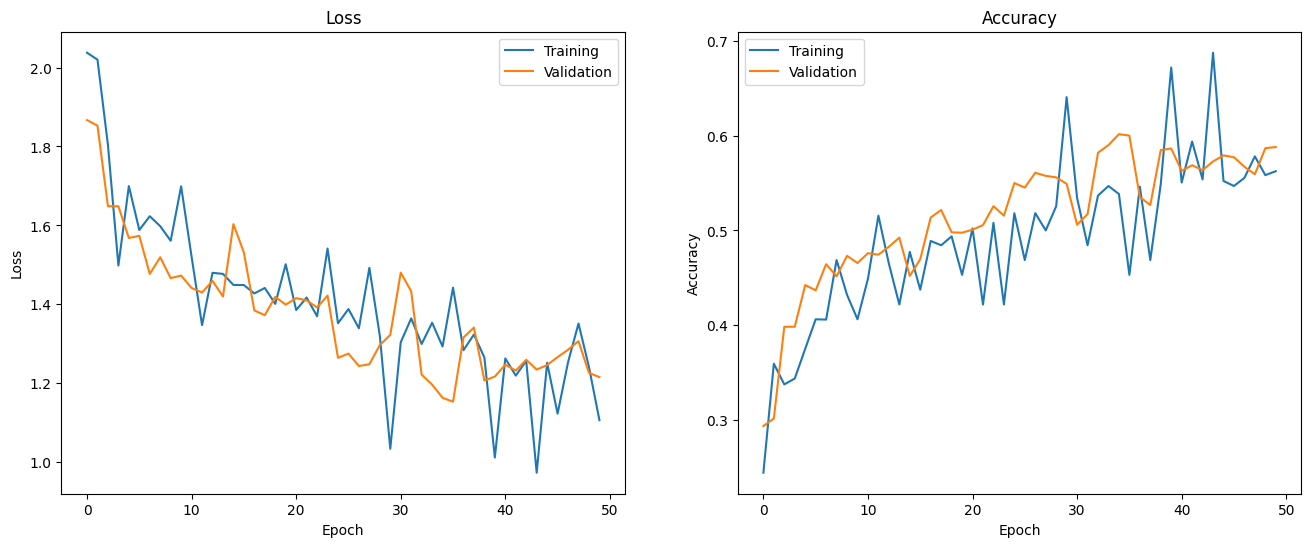

In [20]:
##### YOUR CODE STARTS #####
plot_curves(history)
##### YOUR CODE ENDS #####

### 100 epochs

In [21]:
##### YOUR CODE STARTS #####
test_loss, test_acc = model.evaluate(X_test_norm, y_test, verbose=0)
print(f'Test accuracy: {test_acc:.4f}')
print(f'Test loss: {test_loss:.4f}')
##### YOUR CODE ENDS #####

Test accuracy: 0.5919
Test loss: 1.1861


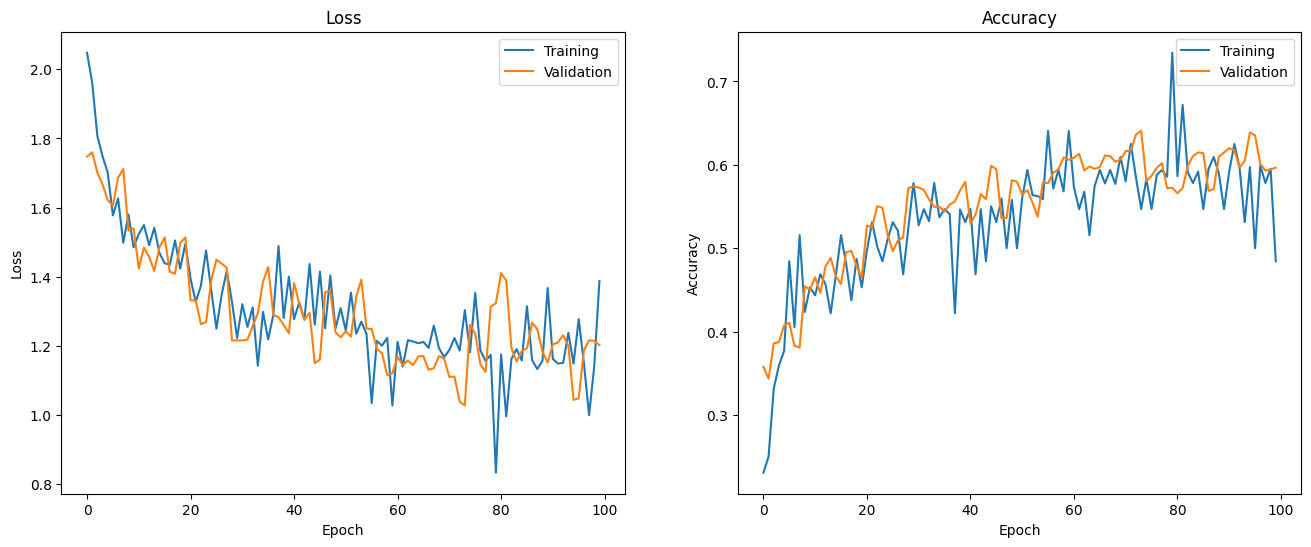

In [23]:
##### YOUR CODE STARTS #####
plot_curves(history)
##### YOUR CODE ENDS #####

In [24]:
##### YOUR CODE STARTS #####
test_loss, test_acc = model.evaluate(X_test_norm, y_test, verbose=0)
print(f'Test accuracy: {test_acc:.4f}')
print(f'Test loss: {test_loss:.4f}')
##### YOUR CODE ENDS #####

Test accuracy: 0.6016
Test loss: 1.1784


<font color='red'> Textual answer to (**c**) goes here: </font>

The performance did not really improve with the extended augmentation pipeline. In class, we got about 77% accuracy in 25 epochs. With the new pipeline, even after 100 epochs, we only reached around 60% accuracy.

The added augmentations (like zoom, brightness, and shear) may have made the training images too complex or unrealistic for a simple model like ours. The model struggled to generalize well from that noisy training data. It probably needed a deeper architecture to benefit from that kind of augumentation.

From the curves, we can see that both training and validation accuracy improve quickly at the start, but around epoch 50, the accuracy starts to plateau. Loss values also stop decreasing much after 50 epochs.

The training curve is noisy, likely due to the strong augmentations. So that training longer didn’t help, and maybe even hurt — possibly due to overfitting on augmented noise or lack of regularization strategies like early stopping.

# Bonus exercises
*(NB, these are optional exercises!)*


## Bonus exercise 1 (2 points):

<font color='red'> Implement basic linear regression and Ridge regression using the closed form solutions (https://stats.stackexchange.com/questions/69205/how-to-derive-the-ridge-regression-solution). Run your implementations on the following synthetic dataset. Compare model coefficients to coefficients produced by `sklearn` functions `LinearRegression` and `Ridge`. Speculate about the difference in coefficients that you observe. </font>

In [2]:
# here we generate a synthetic dataset:
from sklearn.datasets import make_regression

X, y, coefficients = make_regression(
    n_samples=50,
    n_features=4,
    n_informative=1,
    n_targets=1,
    noise=5,
    coef=True,
    random_state=1
)

X.shape

(50, 4)

<font color='red'> Implement closed form solutions for both baseline linear regression and ridge regression (https://stats.stackexchange.com/questions/69205/how-to-derive-the-ridge-regression-solution) on the synthetic dataset: </font>



In [6]:
n, m = X.shape
I = np.identity(m)
lambda_ = 1

##### YOUR CODE STARTS #####
X_bias = np.c_[np.ones(X.shape[0]), X] # this includes bias column for intercept
_, m_plus_1 = X_bias.shape

# Implement baseline linear regression (closed form solution)

# Linear Regression without intercept
w_lin_no_bias = np.linalg.inv(X.T @ X) @ X.T @ y
lr_coef_no_intercept = w_lin_no_bias
lr_intercept_no_bias = 0

# Linear Regression with intercept
w_lin_bias = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ y
lr_intercept = w_lin_bias[0]
lr_coef = w_lin_bias[1:]


# Implement Ridge regression (closed form solution)

# Ridge Regression without intercept
w_ridge_no_bias = np.linalg.inv(X.T @ X + lambda_ * I) @ X.T @ y
lr_ridge_coef_no_intercept = w_ridge_no_bias
lr_ridge_intercept_no_bias = 0

# Ridge Regression with intercept
reg_matrix = np.identity(m_plus_1)
reg_matrix[0, 0] = 0  # the intercept should not be regularized
w_ridge_bias = np.linalg.inv(X_bias.T @ X_bias + lambda_ * reg_matrix) @ X_bias.T @ y
lr_ridge_intercept = w_ridge_bias[0]
lr_ridge_coef = w_ridge_bias[1:]

##### YOUR CODE ENDS #####

In [7]:
from sklearn.linear_model import LinearRegression

# Initialise Linear Regression model from sklearn:
lr = LinearRegression()
lr.fit(X, y)

LinearRegression()

In [8]:
print(lr.coef_)
print(lr.intercept_)

[86.7933953   0.12444455  0.699363   -1.78601527]
-0.21031847531199954


In [9]:
from sklearn.linear_model import Ridge

lr_ridge = Ridge(lambda_, solver='cholesky')
lr_ridge.fit(X, y)

Ridge(alpha=1, solver='cholesky')

In [10]:
print(lr_ridge.coef_)
print(lr_ridge.intercept_)

[84.51986709 -0.59219469  0.22580939 -2.23109663]
0.14955471081851357


<font color='red'>  Compare coefficients you obtained using closed form solution and sklearn implementations. Comment on the difference you observe. </font>



In [12]:
##### YOUR CODE STARTS #####
print("Manual Linear Regression:")
print(f"  With intercept: W1 = {lr_coef}, W0 = {lr_intercept}")
print(f"  Without intercept: W1 = {lr_coef_no_intercept}, W0 = {lr_intercept_no_bias}")

print("\nSklearn LinearRegression:")
print(f"  W1 = {lr.coef_}, W0 = {lr.intercept_}")

print("\nManual Ridge Regression:")
print(f"  With intercept: W1 = {lr_ridge_coef}, W0 = {lr_ridge_intercept}")
print(f"  Without intercept: W1 = {lr_ridge_coef_no_intercept}, W0 = {lr_ridge_intercept_no_bias}")

print("\nSklearn Ridge:")
print(f"  W1 = {lr_ridge.coef_}, W0 = {lr_ridge.intercept_}")
##### YOUR CODE ENDS #####

Manual Linear Regression:
  With intercept: W1 = [86.7933953   0.12444455  0.699363   -1.78601527], W0 = -0.21031847531205816
  Without intercept: W1 = [86.75535728  0.13312632  0.69159991 -1.90311649], W0 = 0

Sklearn LinearRegression:
  W1 = [86.7933953   0.12444455  0.699363   -1.78601527], W0 = -0.21031847531199954

Manual Ridge Regression:
  With intercept: W1 = [84.51986709 -0.59219469  0.22580939 -2.23109663], W0 = 0.1495547108185119
  Without intercept: W1 = [84.54595777 -0.59834829  0.23111543 -2.15037623], W0 = 0

Sklearn Ridge:
  W1 = [84.51986709 -0.59219469  0.22580939 -2.23109663], W0 = 0.14955471081851357


<font color='red'>Your textual answer explaining the difference between coefficients goes here:</font>

In this work, I looked at two versions of the closed-form solution for both linear and ridge regression.

The basic formula was:  
$$\beta = (X^\top X + \lambda I)^{-1} X^\top y$$
This version assumes the model doesn't need a bias (intercept) term. It's simpler, but usually less accurate if the data isn't centered.

Then I added a column of ones to $X$, so the model can learn the intercept. The formula becomessomething like that, I assume:  
$$\beta = (\tilde{X}^\top \tilde{X} + \lambda \tilde{I})^{-1} \tilde{X}^\top y$$  
I also made sure not to regularize the intercept by setting the first value of the identity matrix to zero. This version matches what libraries like `sklearn` do by default.

**Coefficient comparison:**

When the intercept is included and handled properly, both our manual implementations and `sklearn` produce identical results for linear and ridge regression. This confirms that the closed-form solutions work as expected and align with standard library behavior.

However, when the intercept is excluded, the coefficients differ. This happens because the model is forced to fit the data through the origin, which distorts the weight estimates — especially if the target values are not centered around zero.

In ridge regression, the difference is even more noticeable due to regularization: without the intercept, the penalty is applied to weights that may be compensating for the missing bias term, leading to a different balance across features.

## Bonus exercise 2 (up to 4 bonus points depending on presentation):
<font color='red'> Experimentally verify if CutMix augmentation helps to improve the test score on CIFAR10 (not clear, as images are very tiny). Link to the CutMix paper: https://arxiv.org/abs/1905.04899. Show couple of examples of CutMix augmented images and your implementation along with performance curves and scores. Compare the results of CutMix augmented model and the model without data augmentation. </font>


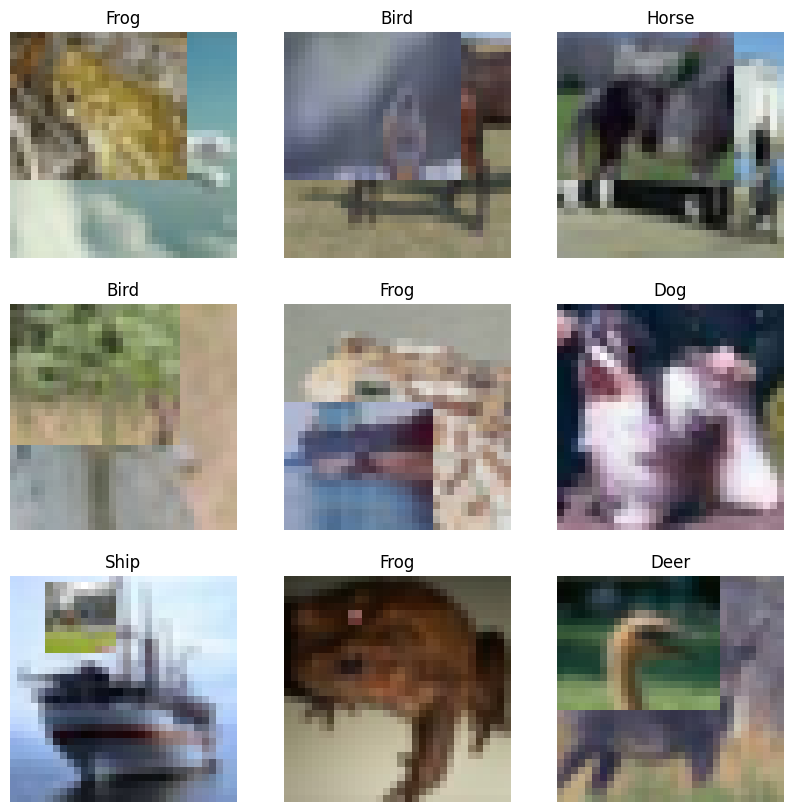

In [26]:
##### YOUR CODE STARTS #####
from tensorflow.data import AUTOTUNE
from tensorflow.keras.utils import to_categorical

class_names = ["Airplane", "Automobile", "Bird", "Cat", "Deer", "Dog", "Frog", "Horse", "Ship", "Truck"]

AUTO = tf_data.AUTOTUNE
BATCH_SIZE = 32
IMG_SIZE = 32

# load and preprocess data
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
X_train = X_train[:25000]
y_train = y_train[:25000]
y_train = keras.utils.to_categorical(y_train, num_classes=10)
y_test = keras.utils.to_categorical(y_test, num_classes=10)

def preprocess_image(image, label):
  image = tf_image.resize(image, (IMG_SIZE, IMG_SIZE))
  image = tf_image.convert_image_dtype(image, "float32") / 255.0
  label = keras.ops.cast(label, dtype="float32")
  return image, label

# two shuffled datasets for CutMix pairing
train_ds_one = (
    tf_data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(1024)
    .map(preprocess_image, num_parallel_calls=AUTO)
)
train_ds_two = (
    tf_data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(1024)
    .map(preprocess_image, num_parallel_calls=AUTO)
)

# vanilla dataset (no augmentation)
train_ds_simple = tf_data.Dataset.from_tensor_slices((X_train, y_train))
test_ds = tf_data.Dataset.from_tensor_slices((X_test, y_test))

train_ds_simple = (
    train_ds_simple.map(preprocess_image, num_parallel_calls=AUTO)
    .batch(BATCH_SIZE)
    .prefetch(AUTO)
)

# combine two shuffled datasets from the same training data
train_ds = tf_data.Dataset.zip((train_ds_one, train_ds_two))
test_ds = (
    test_ds.map(preprocess_image, num_parallel_calls=AUTO)
    .batch(BATCH_SIZE)
    .prefetch(AUTO)
)

# CutMix utilities
def sample_beta_distribution(size, concentration_0=0.2, concentration_1=0.2):
  # samples from two Gamma distributions
  gamma_1_sample = tf_random.gamma(shape=[size], alpha=concentration_1)
  gamma_2_sample = tf_random.gamma(shape=[size], alpha=concentration_0)

  # ratio with Beta distribution
  return gamma_1_sample / (gamma_1_sample + gamma_2_sample)


def get_box(lambda_value):
  cut_rat = keras.ops.sqrt(1.0 - lambda_value) # cut ratio

  # patch width and height
  cut_w = IMG_SIZE * cut_rat  # rw
  cut_w = keras.ops.cast(cut_w, "int32")
  cut_h = IMG_SIZE * cut_rat  # rh
  cut_h = keras.ops.cast(cut_h, "int32")

  # patch random center
  cut_x = keras.random.uniform((1,), minval=0, maxval=IMG_SIZE)  # rx
  cut_x = keras.ops.cast(cut_x, "int32")
  cut_y = keras.random.uniform((1,), minval=0, maxval=IMG_SIZE)  # ry
  cut_y = keras.ops.cast(cut_y, "int32")

  # convert center to box coordinates
  boundaryx1 = clip_by_value(cut_x[0] - cut_w // 2, 0, IMG_SIZE)
  boundaryy1 = clip_by_value(cut_y[0] - cut_h // 2, 0, IMG_SIZE)
  bbx2 = clip_by_value(cut_x[0] + cut_w // 2, 0, IMG_SIZE)
  bby2 = clip_by_value(cut_y[0] + cut_h // 2, 0, IMG_SIZE)

  target_h = bby2 - boundaryy1
  if target_h == 0: # avoid zero-size boxes
      target_h += 1

  target_w = bbx2 - boundaryx1
  if target_w == 0:
      target_w += 1

  return boundaryx1, boundaryy1, target_h, target_w


def cutmix(train_ds_one, train_ds_two):
  (image1, label1), (image2, label2) = train_ds_one, train_ds_two

  alpha = [0.25]
  beta = [0.25]

  lambda_value = sample_beta_distribution(1, alpha, beta)
  lambda_value = lambda_value[0][0]

  boundaryx1, boundaryy1, target_h, target_w = get_box(lambda_value) # image box properties

  # patch from second image
  crop2 = tf_image.crop_to_bounding_box(image2, boundaryy1, boundaryx1, target_h, target_w)
  # pad the patch with same offset
  image2 = tf_image.pad_to_bounding_box(crop2, boundaryy1, boundaryx1, IMG_SIZE, IMG_SIZE)
  # patch from the first image
  crop1 = tf_image.crop_to_bounding_box(image1, boundaryy1, boundaryx1, target_h, target_w)
  # pad the patch
  img1 = tf_image.pad_to_bounding_box(crop1, boundaryy1, boundaryx1, IMG_SIZE, IMG_SIZE)

  image1 = image1 - img1
  image = image1 + image2

  # adjust lambda
  lambda_value = 1 - (target_w * target_h) / (IMG_SIZE * IMG_SIZE)
  lambda_value = keras.ops.cast(lambda_value, "float32")

  # combine labels with ratio
  label = lambda_value * label1 + (1 - lambda_value) * label2

  return image, label

# new dataset
train_ds_cmu = (
    train_ds.shuffle(1024)
    .map(cutmix, num_parallel_calls=AUTO)
    .batch(BATCH_SIZE)
    .prefetch(AUTO)
)

# preview
image_batch, label_batch = next(iter(train_ds_cmu))
plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.title(class_names[np.argmax(label_batch[i])])
    plt.imshow(image_batch[i])
    plt.axis("off")

##### YOUR CODE ENDS #####

In [32]:
model_cutmix = define_model_dropout(dropout_rate=0.25)
model_cutmix.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

history_cutmix = model_cutmix.fit(
    train_ds_cmu,
    validation_data=test_ds,
    epochs=50,
    verbose=1
)

model_vanilla = define_model_dropout(dropout_rate=0.25)
model_vanilla.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

history_vanilla = model_vanilla.fit(
    train_ds_simple,
    validation_data=test_ds,
    epochs=50,
    verbose=1
)

Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.1700 - loss: 2.2049 - val_accuracy: 0.3517 - val_loss: 1.7056
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.3092 - loss: 1.9311 - val_accuracy: 0.4528 - val_loss: 1.5149
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.3655 - loss: 1.8346 - val_accuracy: 0.4762 - val_loss: 1.4335
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4039 - loss: 1.7717 - val_accuracy: 0.5313 - val_loss: 1.3056
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4320 - loss: 1.7157 - val_accuracy: 0.5627 - val_loss: 1.2248
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4557 - loss: 1.6788 - val_accuracy: 0.5970 - val_loss: 1.1442
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4738 - loss: 1.6489 - val_accuracy: 0.6049 - val_loss: 1.1324
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4902 - loss: 1.6069 - val_accuracy: 

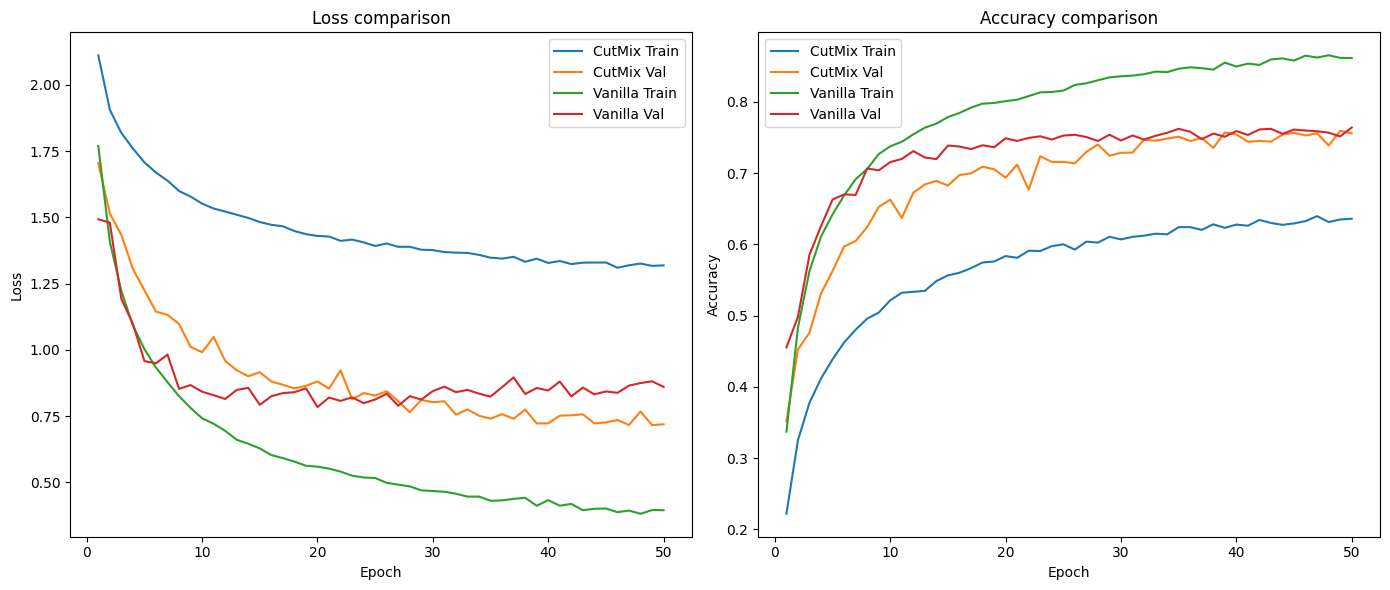


Test accuracy CutMix: 0.7559
Test accuracy Vanilla: 0.7641

Test loss CutMix: 0.7190
Test loss Vanilla: 0.8602


In [33]:
#Comparison part
##### YOUR CODE STARTS #####
def plot_training_curves(history1, history2, label1="CutMix", label2="Vanilla"):
  epochs = range(1, len(history1.history['loss']) + 1)

  plt.figure(figsize=(14, 6))

  plt.subplot(1, 2, 1)
  plt.plot(epochs, history1.history['loss'], label=f'{label1} Train')
  plt.plot(epochs, history1.history['val_loss'], label=f'{label1} Val')
  plt.plot(epochs, history2.history['loss'], label=f'{label2} Train')
  plt.plot(epochs, history2.history['val_loss'], label=f'{label2} Val')
  plt.title('Loss comparison')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()
  plt.subplot(1, 2, 2)
  plt.plot(epochs, history1.history['accuracy'], label=f'{label1} Train')
  plt.plot(epochs, history1.history['val_accuracy'], label=f'{label1} Val')
  plt.plot(epochs, history2.history['accuracy'], label=f'{label2} Train')
  plt.plot(epochs, history2.history['val_accuracy'], label=f'{label2} Val')
  plt.title('Accuracy comparison')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.legend()

  plt.tight_layout()
  plt.show()

plot_training_curves(history_cutmix, history_vanilla)

cutmix_eval = model_cutmix.evaluate(test_ds, verbose=0)
vanilla_eval = model_vanilla.evaluate(test_ds, verbose=0)

print(f"\nTest accuracy CutMix: {cutmix_eval[1]:.4f}")
print(f"Test accuracy Vanilla: {vanilla_eval[1]:.4f}")

print(f"\nTest loss CutMix: {cutmix_eval[0]:.4f}")
print(f"Test loss Vanilla: {vanilla_eval[0]:.4f}")
##### YOUR CODE ENDS #####

<font color='red'> Your explanation: </font>

So, I hoped that fancy image augmentation trick where you mix two pictures together could help a model do better on CIFAR-10. Spoiler: it kinda helped, kinda didn’t.

When it comes to plain accuracy, the vanilla model slightly ourperformed CutMix,not a huge difference, but still...

Hovewer, CutMix model had a lower loss, meaning even though it was wrong a bit more often, it was more confident overall, it made safer mistakes, which is actually a good sign. So it was more calibrated in its predictions.

The training curves were also interesting. The vanilla model learned super fast and hit high accuracy on the training set quickly, but then kinda stopped improving on the validation set — classic overfitting. Meanwhile, the CutMix model took its time, learned more steadily, and kept its validation accuracy smooth and stable. So, I assume, that’s what CutMix is supposed to do: make your model tougher by mixing up its inputs and forcing it to focus on the right things instead of memorizing.

I can agree, that on a bigger dataset or with a more complex model, it might have won.

# Comments (optional feedback to the course instructors)
Here, please, leave your comments regarding the homework, possibly answering the following questions:
* how much time did you send on this homework?
* was it too hard/easy for you?
* what would you suggest to add or remove?
* anything else you would like to tell us

The most time-consuming was the implementation of CutMix, here's what helped me a lot to fix my mistakes, I just tested data types and sizes against the same pypline as here https://keras.io/examples/vision/cutmix/. But it's also the most interesting part, so I'm all for it!

The only advice is to fix outdated imports.